# Motivating PCA

*Course notes for **Math for Machine Learning**, C1 · W4 · L2 · V06b — "Motivating PCA" (DeepLearning.AI).*

Now that we can **project** data onto a line, how does PCA use it to reduce dimensions *well*? The crux: different projection directions **preserve different amounts of spread**, and **more spread = more preserved information**. PCA seeks the direction that keeps the **maximum** spread. We cover:

- **Centering** the data.
- Projecting onto several directions and measuring their **spread (variance)**.
- Ranking directions by information preserved — and what PCA optimizes.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)
%matplotlib inline

## 1. Center the data first

Each dot is an observation with two features $(x, y)$. To go from 2D to 1D we'll project onto a line. But first, since the data usually isn't centered at the origin, we **subtract the mean** so the cloud is centered at $(0,0)$ — projections are then measured about the center.

In [2]:
# An elongated 2-D cloud (reproducible, no argless random calls)
rng = np.random.default_rng(1)
n = 150
t = rng.normal(0, 1.6, n)
main_dir = np.array([2.0, 1.0]); main_dir /= np.linalg.norm(main_dir)
data = np.array([5.0, 3.0]) + t[:, None]*main_dir*2 + rng.normal(0, 0.4, (n, 2))

centered = data - data.mean(axis=0)
print('mean before centering:', data.mean(axis=0))
print('mean after centering :', centered.mean(axis=0))

mean before centering: [4.71  2.899]
mean after centering : [ 0. -0.]


## 2. Project onto different directions and measure spread

We can project onto **any** line. The lecture tries several:

- the **x-axis** (direction $(1,0)$),
- the **y-axis** (direction $(0,1)$),
- the line $y + x = 0$ (direction $(1,-1)$),
- the line $2x - y = 0$ (direction $(1,2)$),
- and a direction that **fits the data well**.

For each, the projected 1D coordinate is $A\,\dfrac{v}{\|v\|}$, and its **spread** is the **variance** of those coordinates. More spread means the projected points stay farther apart — i.e. **more of the original information is retained**.

In [3]:
def project_1d(A, v):
    v = np.asarray(v, dtype=float)
    return A @ (v / np.linalg.norm(v))

candidates = {
    'x-axis  (1,0)':  np.array([1, 0]),
    'y-axis  (0,1)':  np.array([0, 1]),
    'y+x=0   (1,-1)': np.array([1, -1]),
    '2x-y=0  (1,2)':  np.array([1, 2]),
    'data-fit(2,1)':  np.array([2, 1]),
}

spreads = {name: project_1d(centered, v).var() for name, v in candidates.items()}
for name, s in sorted(spreads.items(), key=lambda kv: -kv[1]):
    print(f'{name:16s} variance (spread) = {s:.3f}')

data-fit(2,1)    variance (spread) = 7.965
x-axis  (1,0)    variance (spread) = 6.370
2x-y=0  (1,2)    variance (spread) = 5.195
y-axis  (0,1)    variance (spread) = 1.753
y+x=0   (1,-1)   variance (spread) = 0.914


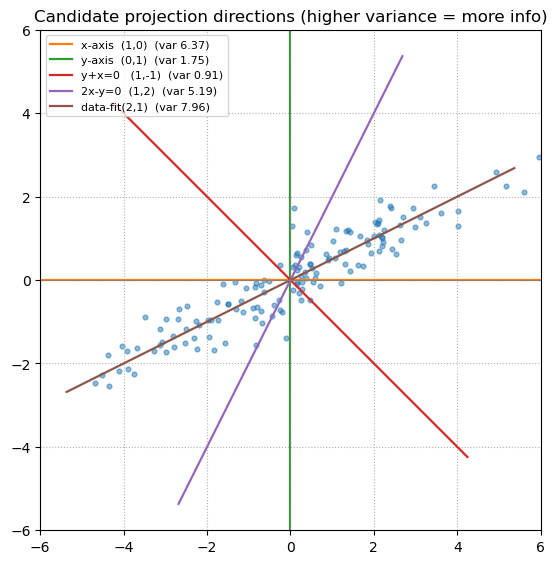

In [4]:
# Visualize the cloud with the candidate lines
fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.scatter(centered[:, 0], centered[:, 1], s=12, color='C0', alpha=0.5)
tt = np.linspace(-6, 6, 2)
colors = ['C1', 'C2', 'C3', 'C4', 'C5']
for (name, v), c in zip(candidates.items(), colors):
    vu = v / np.linalg.norm(v)
    ax.plot(tt*vu[0], tt*vu[1], color=c, lw=1.6, label=f'{name}  (var {spreads[name]:.2f})')
ax.axhline(0, color='gray', lw=0.6); ax.axvline(0, color='gray', lw=0.6)
ax.set_aspect('equal'); ax.grid(True, ls=':'); ax.legend(fontsize=8, loc='upper left')
ax.set_xlim(-6, 6); ax.set_ylim(-6, 6)
ax.set_title('Candidate projection directions (higher variance = more info)')
plt.show()

## 3. More spread = more information

Sorting the projections from **most** spread to **least**: the top one preserves the most information, the bottom one the least. If we sweep the projection direction through **all** angles, the variance traces out a curve with a clear **maximum** — the single best 1D direction to keep.

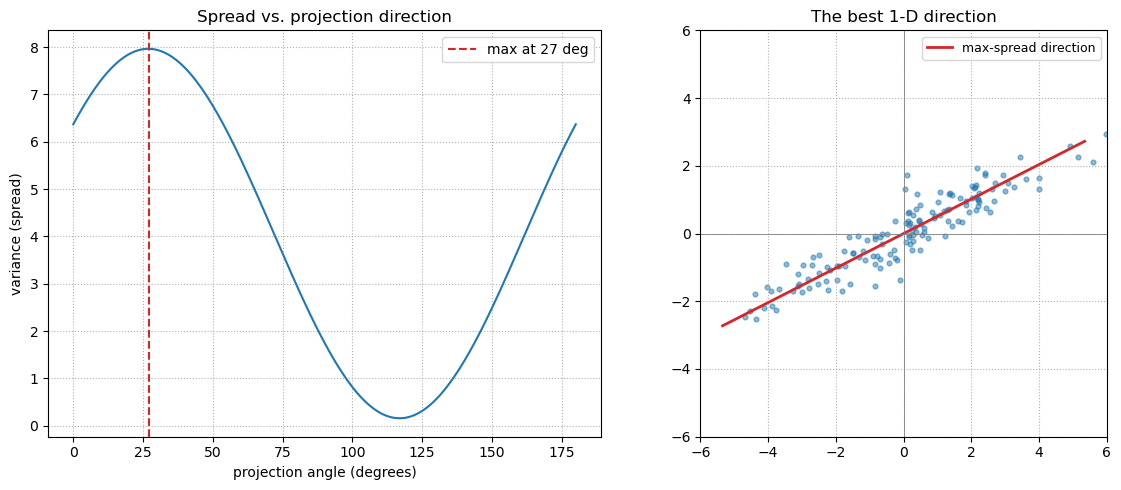

best direction preserves the most spread -> the most information


In [5]:
angles = np.linspace(0, np.pi, 181)
variances = np.array([project_1d(centered, [np.cos(a), np.sin(a)]).var() for a in angles])
best = angles[np.argmax(variances)]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(np.degrees(angles), variances, color='C0')
axes[0].axvline(np.degrees(best), color='C3', ls='--', label=f'max at {np.degrees(best):.0f} deg')
axes[0].set_xlabel('projection angle (degrees)'); axes[0].set_ylabel('variance (spread)')
axes[0].grid(True, ls=':'); axes[0].legend(); axes[0].set_title('Spread vs. projection direction')

# the best direction over the cloud
bd = np.array([np.cos(best), np.sin(best)])
axes[1].scatter(centered[:, 0], centered[:, 1], s=12, color='C0', alpha=0.5)
tt = np.linspace(-6, 6, 2)
axes[1].plot(tt*bd[0], tt*bd[1], 'C3', lw=2, label='max-spread direction')
axes[1].axhline(0, color='gray', lw=0.6); axes[1].axvline(0, color='gray', lw=0.6)
axes[1].set_aspect('equal'); axes[1].grid(True, ls=':'); axes[1].legend(fontsize=9)
axes[1].set_xlim(-6, 6); axes[1].set_ylim(-6, 6); axes[1].set_title('The best 1-D direction')
plt.tight_layout(); plt.show()

print('best direction preserves the most spread -> the most information')

## 4. What PCA does

> **The goal of PCA is to find the projection that preserves the maximum possible spread in the data**, even as it reduces the dimensionality.

Benefits of dimensionality reduction, and PCA specifically:

- **Smaller** datasets are easier to manage.
- PCA reduces dimensions while **minimizing information loss** (keeping maximum spread).
- This enables **analysis and visualization** that weren't feasible in the original high-dimensional space.

The next videos show *how* PCA actually finds that maximum-spread direction — it turns out to be an **eigenvector** of the data's **covariance matrix**.

## Summary

- PCA reduces dimensions by **projecting** — but the **choice of direction** matters: different directions keep different amounts of **spread**.
- **Center** the data first (subtract the mean); measure a projection's spread by the **variance** of the projected coordinates.
- **More spread $=$ more preserved information.** Ranking directions by variance identifies the best one; sweeping all angles shows a clear maximum.
- **PCA finds the maximum-spread projection**, minimizing information loss — and that optimal direction is an **eigenvector of the covariance matrix** (coming next).